In [12]:
from src.utils import CropTransform, SegmentationModel
from src.utils import Browser

from transformers.image_utils import load_image
from pathlib import Path
import cv2
import numpy as np

In [13]:
def mask_to_yolo_polygon(mask, img_width, img_height, epsilon_factor=0.002):
    """
    Convert a SAM binary mask to YOLO segmentation format.
    mask: 2D numpy bool/uint8 array (H, W)
    """
    mask_uint8 = mask.astype(np.uint8) * 255
    
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return None
    
    # Take the largest contour (in case SAM returns noisy fragments)
    contour = max(contours, key=cv2.contourArea)
    
    # Simplify the contour (fewer points, still accurate)
    epsilon = epsilon_factor * cv2.arcLength(contour, True)
    simplified = cv2.approxPolyDP(contour, epsilon, True)
    
    # Normalize to 0-1
    points = simplified.reshape(-1, 2)
    points = points.astype(float)
    points[:, 0] /= img_width
    points[:, 1] /= img_height
    
    # Clamp to [0, 1] just in case
    points = np.clip(points, 0, 1)
    
    # Format as YOLO line: "0 x1 y1 x2 y2 ..."
    flat = points.flatten()
    yolo_line = "0 " + " ".join(f"{v:.6f}" for v in flat)
    
    return yolo_line

In [38]:
src_path = "/home/timothee/Documents/programmation/DIHT/data/yolo_dataset/images"
output_path = "/home/timothee/Documents/programmation/DIHT/data/yolo_dataset"
device = "cuda"
objects = ["bottle cap"]

In [4]:
crop_model = CropTransform(device, objects)
segmentation_model = SegmentationModel(device)

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

In [52]:
with open('/'.join([output_path, "train.txt"])) as f:
    image_paths = [Path(line.strip()) for line in f.readlines()]

failed = []

for image_path in image_paths:
    img = load_image(image_path.as_posix())
    img_arr = np.array(img)
    h, w = img_arr.shape[:2]
    box = crop_model.get_cropbox(img)
    seg_mask = segmentation_model.get_mask(img, [box])

    line = mask_to_yolo_polygon(seg_mask, w, h)
    if not line:
        failed.append(image_path)
        continue
    
    label_path = Path(str(image_path).replace("/images/", "/labels/")).with_suffix(".txt")
    label_path.parent.mkdir(parents=True, exist_ok=True)

    with open(label_path, "w") as f:
        f.write(line)

print(f"{len(failed)} images got no mask:")
for p in failed: print(" ", p)

0 images got no mask:


In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def plot_yolo_mask(image, yolo_line, alpha=0.4):
    """
    Plot image with YOLO segmentation polygon overlaid.
    image: numpy array (H, W, 3) in RGB
    yolo_line: string in YOLO format "0 x1 y1 x2 y2 ..."
    """
    h, w = image.shape[:2]

    # Parse the YOLO line
    values = list(map(float, yolo_line.split()[1:]))  # skip class_id
    points = np.array(values).reshape(-1, 2)

    # Denormalize
    points[:, 0] *= w
    points[:, 1] *= h
    points = points.astype(np.int32)

    # Draw filled mask
    overlay = image.copy()
    cv2.fillPoly(overlay, [points], color=(0, 255, 0))

    # Blend with original
    blended = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

    # Draw polygon outline
    cv2.polylines(blended, [points], isClosed=True, color=(0, 255, 0), thickness=2)

    plt.figure(figsize=(8, 8))
    plt.imshow(blended)
    plt.axis("off")
    plt.title(f"Mask — {len(points)} polygon points")
    plt.tight_layout()
    plt.show()

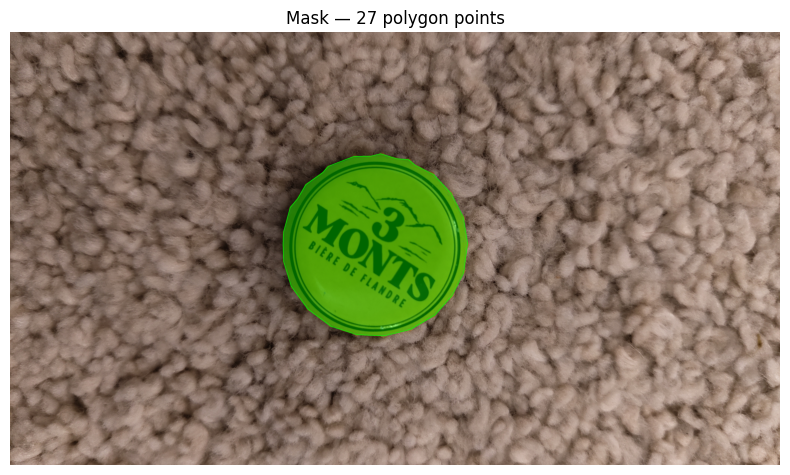

In [51]:
plot_yolo_mask(np.array(img), line)

In [39]:
from pathlib import Path

dataset_root = Path(src_path)

# Collect all images
image_paths = list(dataset_root.rglob("*.jpg")) + \
              list(dataset_root.rglob("*.png"))

# Write to a txt file
with open('/'.join([output_path, "train.txt"]), "w") as f:
    f.write("\n".join(str(p) for p in image_paths))

In [53]:
import random
from pathlib import Path

image_paths = list(Path('/'.join([output_path, "images"])).rglob("*.jpg")) + \
              list(Path('/'.join([output_path, "images"])).rglob("*.png"))

random.shuffle(image_paths)
split = int(len(image_paths) * 0.8)

with open('/'.join([output_path, "train.txt"]), "w") as f:
    f.write("\n".join(str(p) for p in image_paths[:split]))

with open('/'.join([output_path, "val.txt"]), "w") as f:
    f.write("\n".join(str(p) for p in image_paths[split:]))